# Patient-Aware Freezing-of-Gait Classification

This notebook builds a classical machine-learning model from lower-back accelerometer windows. It predicts four classes: **no FoG**, **start hesitation**, **turning freeze**, and **walking freeze**.

The central methodological safeguard is group separation: every recording from a subject stays entirely in either training or testing. This avoids optimistic leakage from patient-specific gait signatures.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FS = 128
WINDOW_SECONDS = 2
WINDOW_SIZE = FS * WINDOW_SECONDS
HOP_SIZE = WINDOW_SIZE // 2
MIN_EVENT_FRACTION = 0.10
SIGNAL_COLUMNS = ["AccV", "AccML", "AccAP"]
EVENT_COLUMNS = ["StartHesitation", "Turn", "Walking"]
CLASS_NAMES = ["No FoG", "Start hesitation", "Turning freeze", "Walking freeze"]
RANDOM_STATE = 42

## Window definition and features

Recordings are divided into two-second windows with 50% overlap. A window is assigned an FoG class when at least 10% of its samples carry an event label; if multiple event labels occur, the class with the most labeled samples wins. This retains boundary windows without treating a single noisy sample as an event.

For each axis and acceleration magnitude, the pipeline extracts distribution, energy, jerk, dominant-frequency, locomotor-band (0.5–3 Hz), freeze-band (3–8 Hz), freeze-index, and spectral-entropy features. Axis correlations are added to capture movement coordination.

In [2]:
def signal_features(values, prefix):
    values = np.asarray(values, dtype=np.float64)
    centered = values - values.mean()
    spectrum = np.fft.rfft(centered * np.hanning(len(centered)))
    frequencies = np.fft.rfftfreq(len(centered), d=1 / FS)
    power = np.abs(spectrum) ** 2
    positive_power = power.copy()
    positive_power[0] = 0
    locomotor = power[(frequencies >= 0.5) & (frequencies < 3.0)].sum()
    freeze = power[(frequencies >= 3.0) & (frequencies <= 8.0)].sum()
    probabilities = power / (power.sum() + 1e-12)
    q25, q75 = np.quantile(values, [0.25, 0.75])
    return {
        f"{prefix}_mean": values.mean(),
        f"{prefix}_std": values.std(),
        f"{prefix}_min": values.min(),
        f"{prefix}_max": values.max(),
        f"{prefix}_iqr": q75 - q25,
        f"{prefix}_rms": np.sqrt(np.mean(values ** 2)),
        f"{prefix}_jerk_rms": np.sqrt(np.mean((np.diff(values) * FS) ** 2)),
        f"{prefix}_dominant_hz": frequencies[np.argmax(positive_power)],
        f"{prefix}_locomotor_power": np.log1p(locomotor),
        f"{prefix}_freeze_power": np.log1p(freeze),
        f"{prefix}_freeze_index": np.log((freeze + 1e-9) / (locomotor + 1e-9)),
        f"{prefix}_spectral_entropy": -(probabilities * np.log(probabilities + 1e-12)).sum(),
    }


def extract_recording_windows(path, recording_id, subject, medication):
    frame = pd.read_csv(
        path,
        usecols=SIGNAL_COLUMNS + EVENT_COLUMNS,
        dtype={column: "float32" for column in SIGNAL_COLUMNS} | {column: "int8" for column in EVENT_COLUMNS},
    )
    signals = frame[SIGNAL_COLUMNS].to_numpy()
    labels = frame[EVENT_COLUMNS].to_numpy()
    rows = []
    for start in range(0, len(frame) - WINDOW_SIZE + 1, HOP_SIZE):
        stop = start + WINDOW_SIZE
        window = signals[start:stop]
        event_counts = labels[start:stop].sum(axis=0)
        target = int(np.argmax(event_counts) + 1) if event_counts.max() >= MIN_EVENT_FRACTION * WINDOW_SIZE else 0
        magnitude = np.linalg.norm(window, axis=1)
        features = {
            "Id": recording_id,
            "Subject": subject,
            "Medication": medication,
            "window_start_s": start / FS,
            "target": target,
        }
        for index, column in enumerate(SIGNAL_COLUMNS):
            features.update(signal_features(window[:, index], column))
        features.update(signal_features(magnitude, "Magnitude"))
        correlation = np.nan_to_num(np.corrcoef(window, rowvar=False), nan=0.0)
        features.update({
            "corr_V_ML": correlation[0, 1],
            "corr_V_AP": correlation[0, 2],
            "corr_ML_AP": correlation[1, 2],
        })
        rows.append(features)
    return rows

## Build or load the feature table

Feature extraction is cached to CSV. Delete the cache only when changing the window or feature definitions.

In [3]:
cache_path = PROCESSED_DIR / f"tdcsfog_features_{WINDOW_SECONDS}s.csv"
metadata = pd.read_csv(RAW_DIR / "tdcsfog_metadata.csv", dtype={"Id": str, "Subject": str})
available_ids = {path.stem for path in RAW_DIR.glob("*.csv")}
metadata = metadata[metadata["Id"].isin(available_ids)].copy()

if cache_path.exists():
    windows = pd.read_csv(cache_path, dtype={"Id": str, "Subject": str})
    print(f"Loaded cached features from {cache_path}")
else:
    extracted = []
    for index, row in enumerate(metadata.itertuples(index=False), 1):
        extracted.extend(extract_recording_windows(RAW_DIR / f"{row.Id}.csv", row.Id, row.Subject, row.Medication))
        if index % 100 == 0 or index == len(metadata):
            print(f"Processed {index}/{len(metadata)} recordings")
    windows = pd.DataFrame(extracted)
    windows.to_csv(cache_path, index=False)
    print(f"Saved features to {cache_path}")

windows["target_name"] = windows["target"].map(dict(enumerate(CLASS_NAMES)))
feature_columns = [
    column for column in windows.columns
    if column not in {"Id", "Subject", "Medication", "window_start_s", "target", "target_name"}
]

summary = pd.Series({
    "windows": len(windows),
    "features": len(feature_columns),
    "recordings": windows["Id"].nunique(),
    "subjects": windows["Subject"].nunique(),
})
display(summary.to_frame("value"))

Loaded cached features from /home/mathew/Arrakis/da-mp/data/processed/tdcsfog_features_2s.csv


,value
windows,25689
features,51
recordings,506
subjects,60


## Feature-space overview

Class imbalance remains after windowing. PCA is shown only as a two-dimensional diagnostic; the classifiers use the complete feature table.

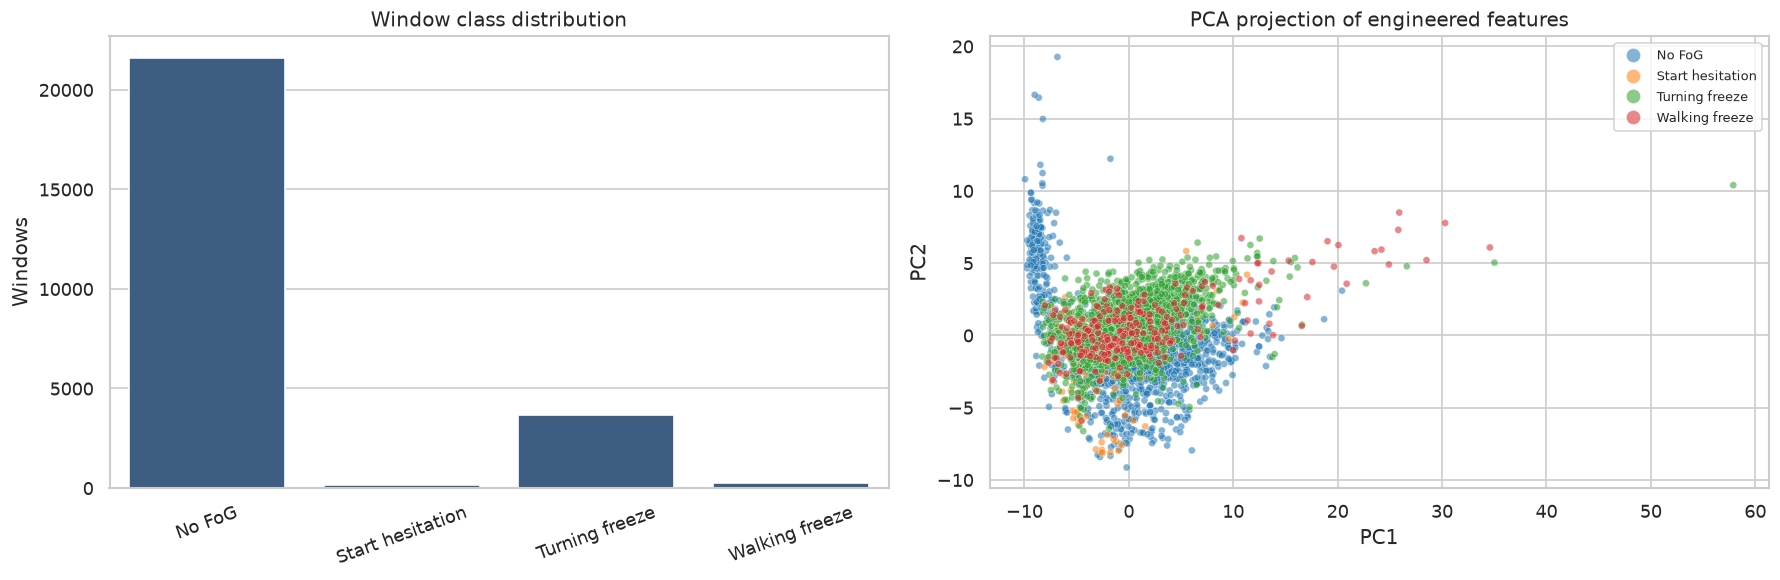

,windows,percent
target_name,,
No FoG,21604,84.10
Start hesitation,162,0.63
Turning freeze,3663,14.26
Walking freeze,260,1.01


In [4]:
class_counts = windows["target_name"].value_counts().reindex(CLASS_NAMES)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], color="#315c8d")
axes[0].set(title="Window class distribution", xlabel="", ylabel="Windows")
axes[0].tick_params(axis="x", rotation=20)

pca_sample = pd.concat([
    group.sample(min(len(group), 2000), random_state=RANDOM_STATE)
    for _, group in windows.groupby("target", sort=True)
], ignore_index=True)
scaled_sample = StandardScaler().fit_transform(pca_sample[feature_columns])
embedding = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled_sample)
pca_frame = pd.DataFrame({"PC1": embedding[:, 0], "PC2": embedding[:, 1], "Class": pca_sample["target_name"]})
sns.scatterplot(data=pca_frame, x="PC1", y="PC2", hue="Class", alpha=0.55, s=18, ax=axes[1], palette="tab10")
axes[1].set_title("PCA projection of engineered features")
axes[1].legend(markerscale=2, fontsize=8)
fig.tight_layout()
plt.show()

display(class_counts.rename("windows").to_frame().assign(percent=lambda x: 100 * x["windows"] / x["windows"].sum()).round(2))

## Patient-level holdout and cross-validation

Twenty percent of subjects form an untouched test set. The remaining subjects are used for five-fold stratified group cross-validation. Model selection is based on macro F1 and balanced accuracy, both of which give minority FoG classes more influence than ordinary accuracy.

In [5]:
X = windows[feature_columns]
y = windows["target"].astype(int)
groups = windows["Subject"]
all_classes = set(range(len(CLASS_NAMES)))

splitter = GroupShuffleSplit(n_splits=100, test_size=0.20, random_state=RANDOM_STATE)
for train_index, test_index in splitter.split(X, y, groups):
    if set(y.iloc[train_index]) == all_classes and set(y.iloc[test_index]) == all_classes:
        break
else:
    raise RuntimeError("Could not create a patient-level split containing every class")

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
groups_train = groups.iloc[train_index]
test_subjects = sorted(groups.iloc[test_index].unique())

split_summary = pd.DataFrame({
    "partition": ["Train", "Test"],
    "windows": [len(train_index), len(test_index)],
    "subjects": [groups_train.nunique(), len(test_subjects)],
    "FoG windows": [(y_train > 0).sum(), (y_test > 0).sum()],
})
display(split_summary)
print(f"Held-out subjects ({len(test_subjects)}): {', '.join(test_subjects)}")

,partition,windows,subjects,FoG windows
0,Train,20072,48,3486
1,Test,5617,12,599


Held-out subjects (12): 02bc69, 231c3b, 312788, 31d269, 7688c1, 7fcee9, bc3908, c7fee4, c8e721, d8836b, e9fc55, f62eec


,model,macro_f1_mean,macro_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
2,Balanced random forest,0.362,0.047,0.347,0.039
1,Balanced logistic regression,0.302,0.022,0.413,0.057
0,Class-prior baseline,0.226,0.002,0.250,0.000


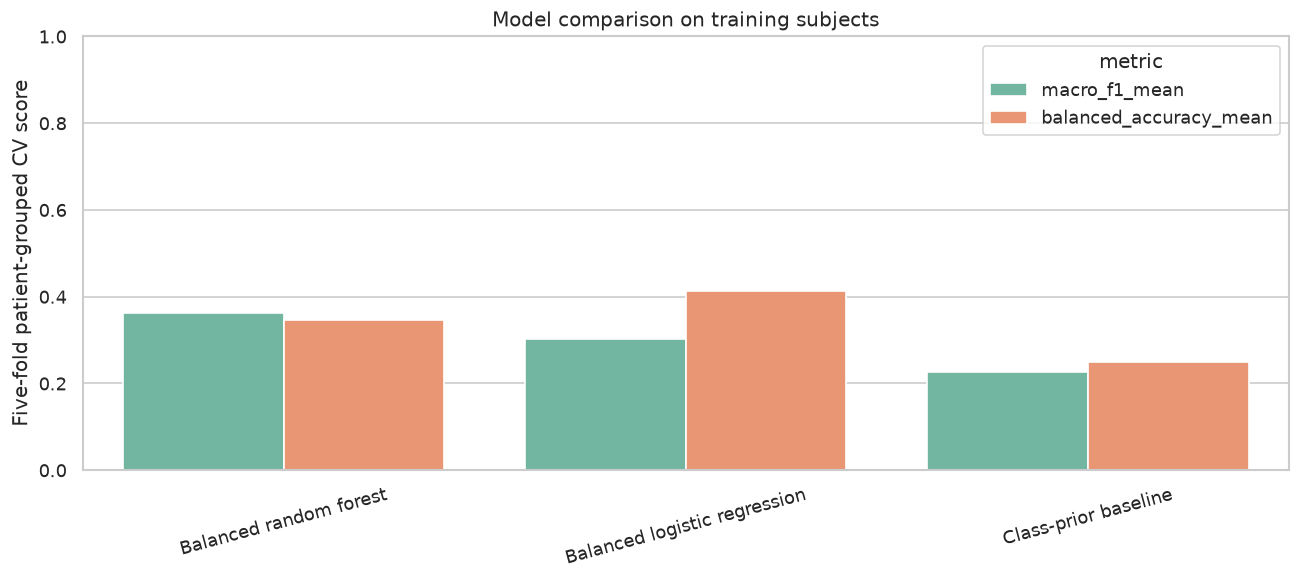

In [6]:
models = {
    "Class-prior baseline": DummyClassifier(strategy="prior"),
    "Balanced logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1500, random_state=RANDOM_STATE)),
    ]),
    "Balanced random forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"macro_f1": "f1_macro", "balanced_accuracy": "balanced_accuracy"}
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, groups=groups_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "model": name,
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_sd": scores["test_macro_f1"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_sd": scores["test_balanced_accuracy"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("macro_f1_mean", ascending=False)
display(cv_results.style.format({column: "{:.3f}" for column in cv_results.columns if column != "model"}))

plot_frame = cv_results.melt(
    id_vars="model",
    value_vars=["macro_f1_mean", "balanced_accuracy_mean"],
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(11, 5))
sns.barplot(data=plot_frame, x="model", y="score", hue="metric", palette="Set2")
plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Five-fold patient-grouped CV score")
plt.title("Model comparison on training subjects")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Final evaluation on unseen subjects

The highest-CV-macro-F1 model is fitted once on all training subjects and evaluated once on the untouched subjects. The normalized confusion matrix emphasizes per-class recall; precision–recall curves expose performance under class imbalance.

,value
selected model,Balanced random forest
macro F1,0.332473
balanced accuracy,0.313684
binary FoG F1,0.380048
macro average precision,0.381681


,precision,recall,f1-score,support
No FoG,0.918,0.983,0.950,5018.000
Start hesitation,0.000,0.000,0.000,14.000
Turning freeze,0.635,0.271,0.380,564.000
Walking freeze,0.000,0.000,0.000,21.000
accuracy,0.906,0.906,0.906,0.906
macro avg,0.388,0.314,0.332,5617.000
weighted avg,0.884,0.906,0.887,5617.000


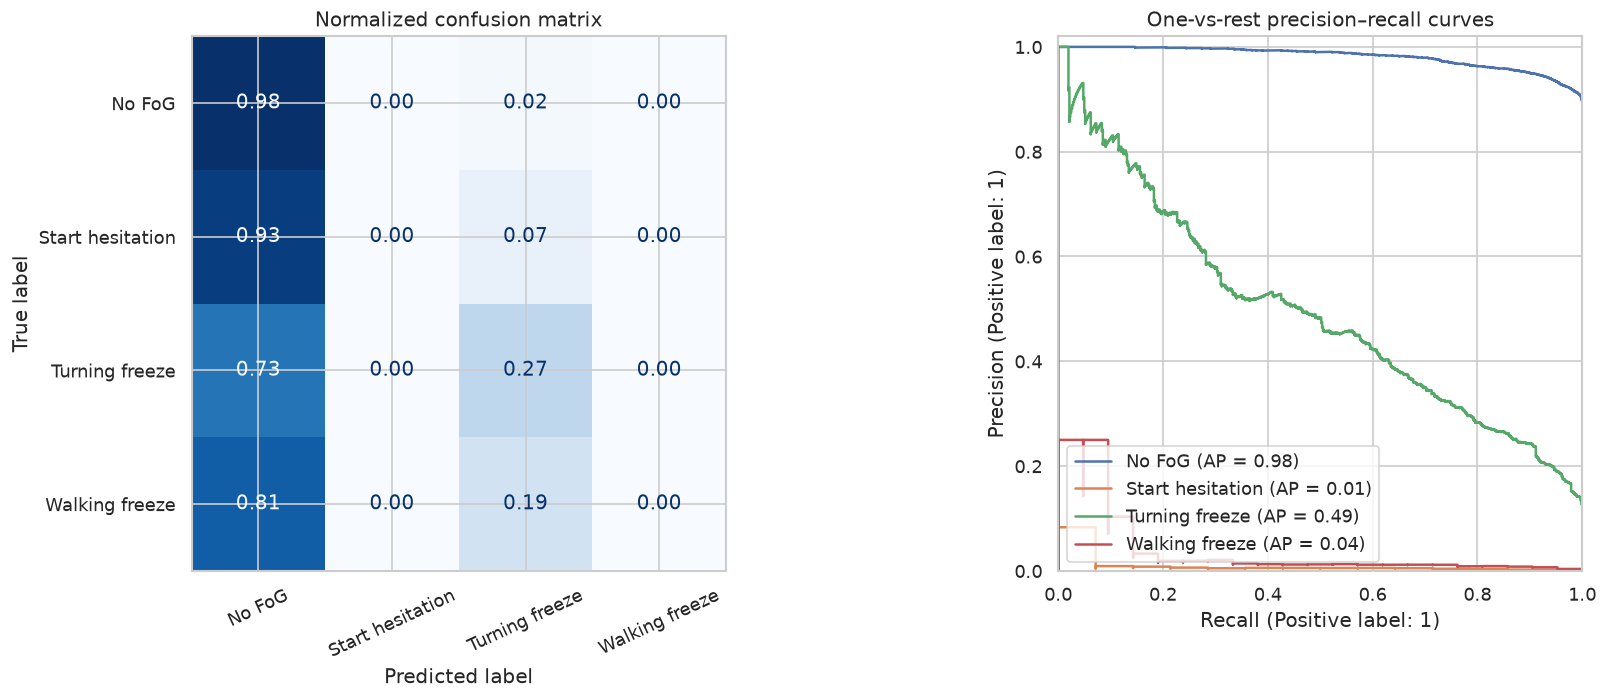

In [7]:
best_name = cv_results.iloc[0]["model"]
best_model = clone(models[best_name]).fit(X_train, y_train)
predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)

report = pd.DataFrame(classification_report(
    y_test,
    predictions,
    labels=range(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)).T

holdout_metrics = pd.Series({
    "selected model": best_name,
    "macro F1": f1_score(y_test, predictions, average="macro"),
    "balanced accuracy": balanced_accuracy_score(y_test, predictions),
    "binary FoG F1": f1_score(y_test > 0, predictions > 0),
    "macro average precision": average_precision_score(
        label_binarize(y_test, classes=range(len(CLASS_NAMES))),
        probabilities,
        average="macro",
    ),
})
display(holdout_metrics.to_frame("value"))
display(report.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=range(len(CLASS_NAMES)),
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Normalized confusion matrix")
axes[0].tick_params(axis="x", rotation=25)

y_test_binary = label_binarize(y_test, classes=range(len(CLASS_NAMES)))
for class_index, class_name in enumerate(CLASS_NAMES):
    PrecisionRecallDisplay.from_predictions(
        y_test_binary[:, class_index],
        probabilities[:, class_index],
        name=class_name,
        ax=axes[1],
    )
axes[1].set_title("One-vs-rest precision–recall curves")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

## App-focused binary FoG detector

Distinguishing three FoG manifestations is harder than answering the application’s immediate question: “is the patient freezing now?” A separate binary detector is therefore selected with grouped cross-validation rather than merely collapsing multiclass predictions. Event-type classification remains available as secondary output.

,model,f1_mean,f1_sd,balanced_accuracy_mean,average_precision_mean
2,Balanced histogram boosting,0.594,0.060,0.773,0.659
1,Balanced extra trees,0.572,0.108,0.725,0.666
0,Balanced logistic regression,0.519,0.063,0.753,0.568


,held-out value
selected model,Balanced histogram boosting
F1,0.48709
balanced accuracy,0.742993
average precision,0.500823


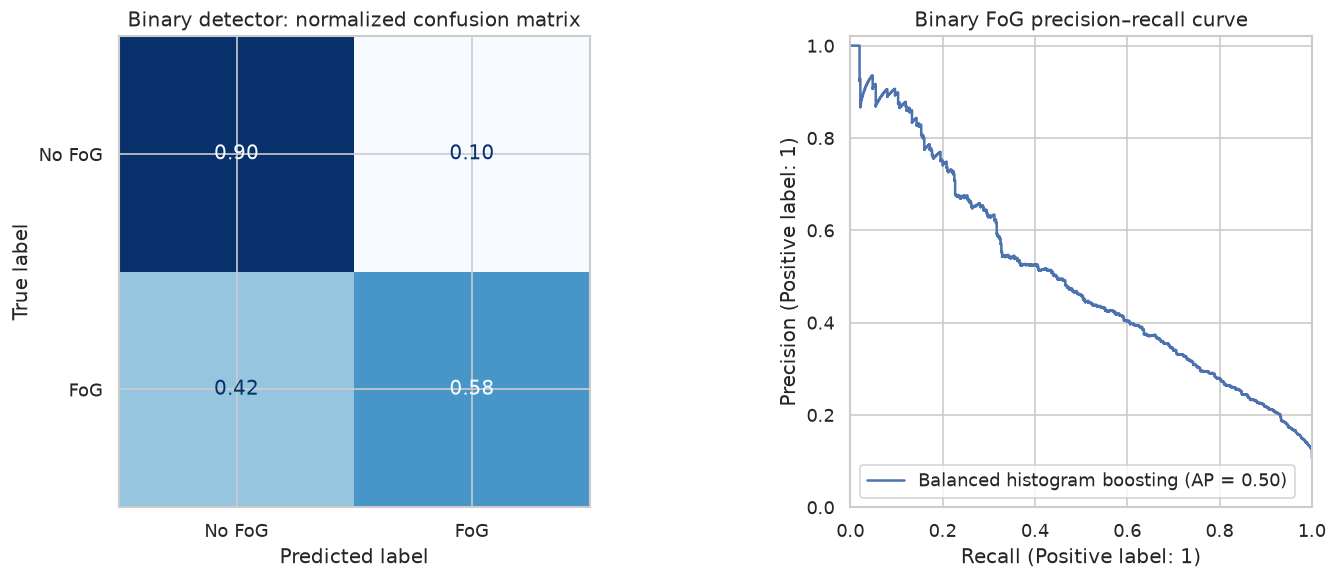

In [8]:
y_train_binary = y_train > 0
y_test_binary_fog = y_test > 0
binary_models = {
    "Balanced logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1500, random_state=RANDOM_STATE)),
    ]),
    "Balanced extra trees": ExtraTreesClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        class_weight="balanced",
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Balanced histogram boosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

binary_rows = []
for name, model in binary_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train_binary,
        groups=groups_train,
        cv=cv,
        scoring={"f1": "f1", "balanced_accuracy": "balanced_accuracy", "average_precision": "average_precision"},
        n_jobs=1,
    )
    binary_rows.append({
        "model": name,
        "f1_mean": scores["test_f1"].mean(),
        "f1_sd": scores["test_f1"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "average_precision_mean": scores["test_average_precision"].mean(),
    })

binary_cv_results = pd.DataFrame(binary_rows).sort_values("f1_mean", ascending=False)
binary_best_name = binary_cv_results.iloc[0]["model"]
binary_model = clone(binary_models[binary_best_name]).fit(X_train, y_train_binary)
binary_probability = binary_model.predict_proba(X_test)[:, 1]
binary_prediction = binary_probability >= 0.5
binary_metrics = pd.Series({
    "selected model": binary_best_name,
    "F1": f1_score(y_test_binary_fog, binary_prediction),
    "balanced accuracy": balanced_accuracy_score(y_test_binary_fog, binary_prediction),
    "average precision": average_precision_score(y_test_binary_fog, binary_probability),
})

display(binary_cv_results.style.format({column: "{:.3f}" for column in binary_cv_results.columns if column != "model"}))
display(binary_metrics.to_frame("held-out value"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_binary_fog,
    binary_prediction,
    display_labels=["No FoG", "FoG"],
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Binary detector: normalized confusion matrix")
PrecisionRecallDisplay.from_predictions(y_test_binary_fog, binary_probability, name=binary_best_name, ax=axes[1])
axes[1].set(title="Binary FoG precision–recall curve", xlim=(0, 1), ylim=(0, 1.02))
fig.tight_layout()
plt.show()

## Subject-level performance and model interpretation

Aggregate scores reveal whether the overall result is dominated by a few patients. Feature importance is impurity-based for the random forest and mean absolute standardized coefficient magnitude for logistic regression.

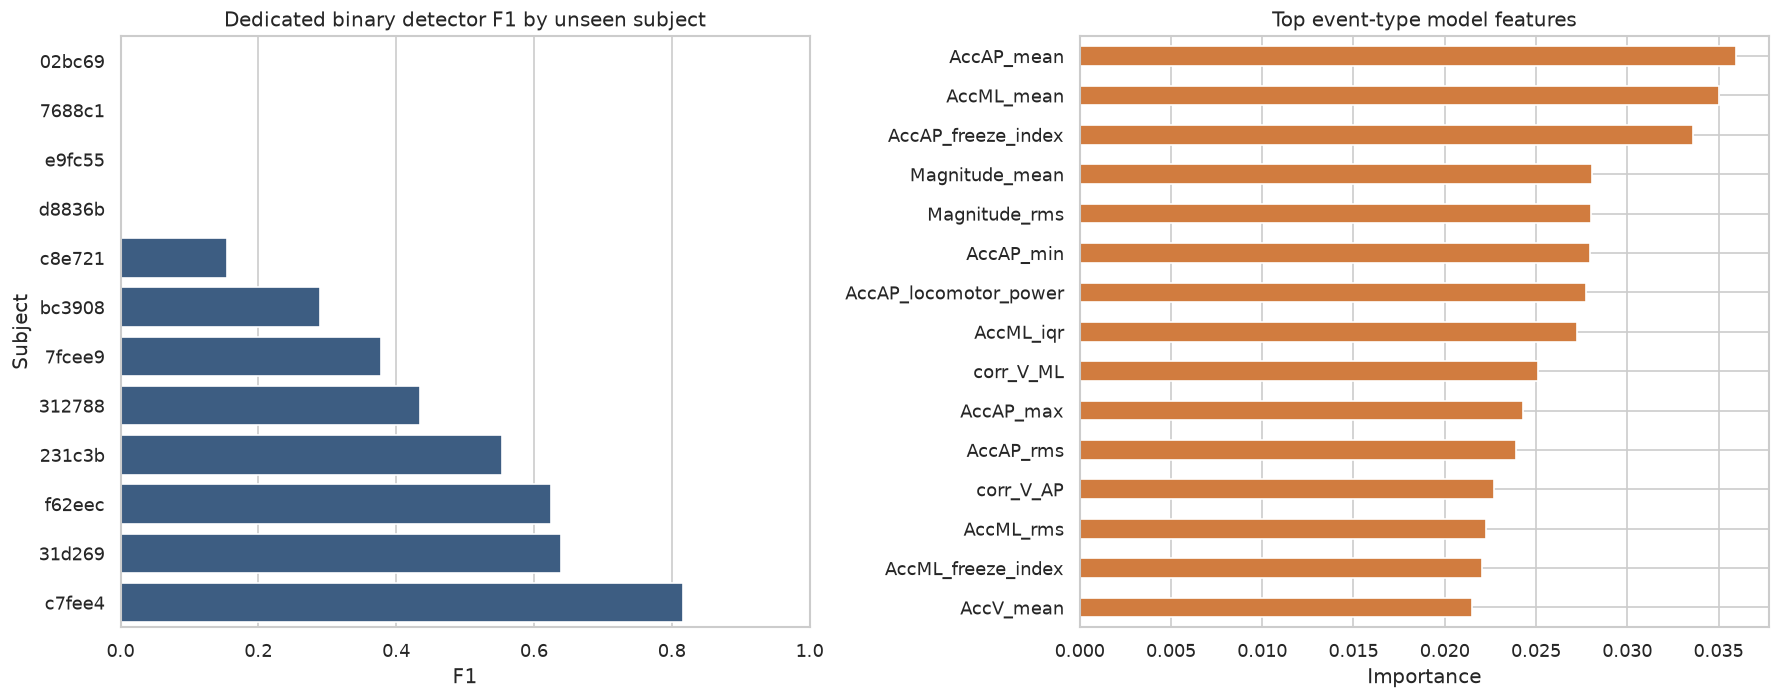

,Subject,binary_fog_f1,actual_burden_pct,predicted_burden_pct,windows
0,02bc69,0.00,0.00,27.78,270
4,7688c1,0.00,0.00,12.64,261
10,e9fc55,0.00,0.00,1.02,196
9,d8836b,0.00,0.00,0.64,467
8,c8e721,0.15,10.03,1.31,688
6,bc3908,0.29,4.61,18.83,738
5,7fcee9,0.38,3.63,9.97,662
2,312788,0.43,3.79,4.92,264
1,231c3b,0.55,23.15,17.59,648
11,f62eec,0.62,26.97,31.35,571


In [9]:
test_results = windows.iloc[test_index][["Subject", "Id", "window_start_s", "target"]].copy()
test_results["prediction"] = predictions
test_results["actual_fog"] = test_results["target"] > 0
test_results["predicted_fog"] = binary_prediction
test_results["fog_probability"] = binary_probability

patient_rows = []
for subject, group in test_results.groupby("Subject"):
    patient_rows.append({
        "Subject": subject,
        "binary_fog_f1": f1_score(group["actual_fog"], group["predicted_fog"], zero_division=0),
        "actual_burden_pct": 100 * group["actual_fog"].mean(),
        "predicted_burden_pct": 100 * group["predicted_fog"].mean(),
        "windows": len(group),
    })
patient_performance = pd.DataFrame(patient_rows).sort_values("binary_fog_f1")

if isinstance(best_model, RandomForestClassifier):
    importance_values = best_model.feature_importances_
elif isinstance(best_model, Pipeline):
    importance_values = np.abs(best_model.named_steps["model"].coef_).mean(axis=0)
else:
    importance_values = np.zeros(len(feature_columns))
feature_importance = pd.Series(importance_values, index=feature_columns).nlargest(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=patient_performance, y="Subject", x="binary_fog_f1", ax=axes[0], color="#315c8d")
axes[0].set(title="Dedicated binary detector F1 by unseen subject", xlim=(0, 1), xlabel="F1", ylabel="Subject")
feature_importance.plot.barh(ax=axes[1], color="#d17c3f")
axes[1].set(title="Top event-type model features", xlabel="Importance", ylabel="")
fig.tight_layout()
plt.show()

display(patient_performance.round(2))

## Example prediction timeline

Window probabilities are shown for the held-out recording containing the most FoG windows. This view is closer to how an application would display model output than a single aggregate score.

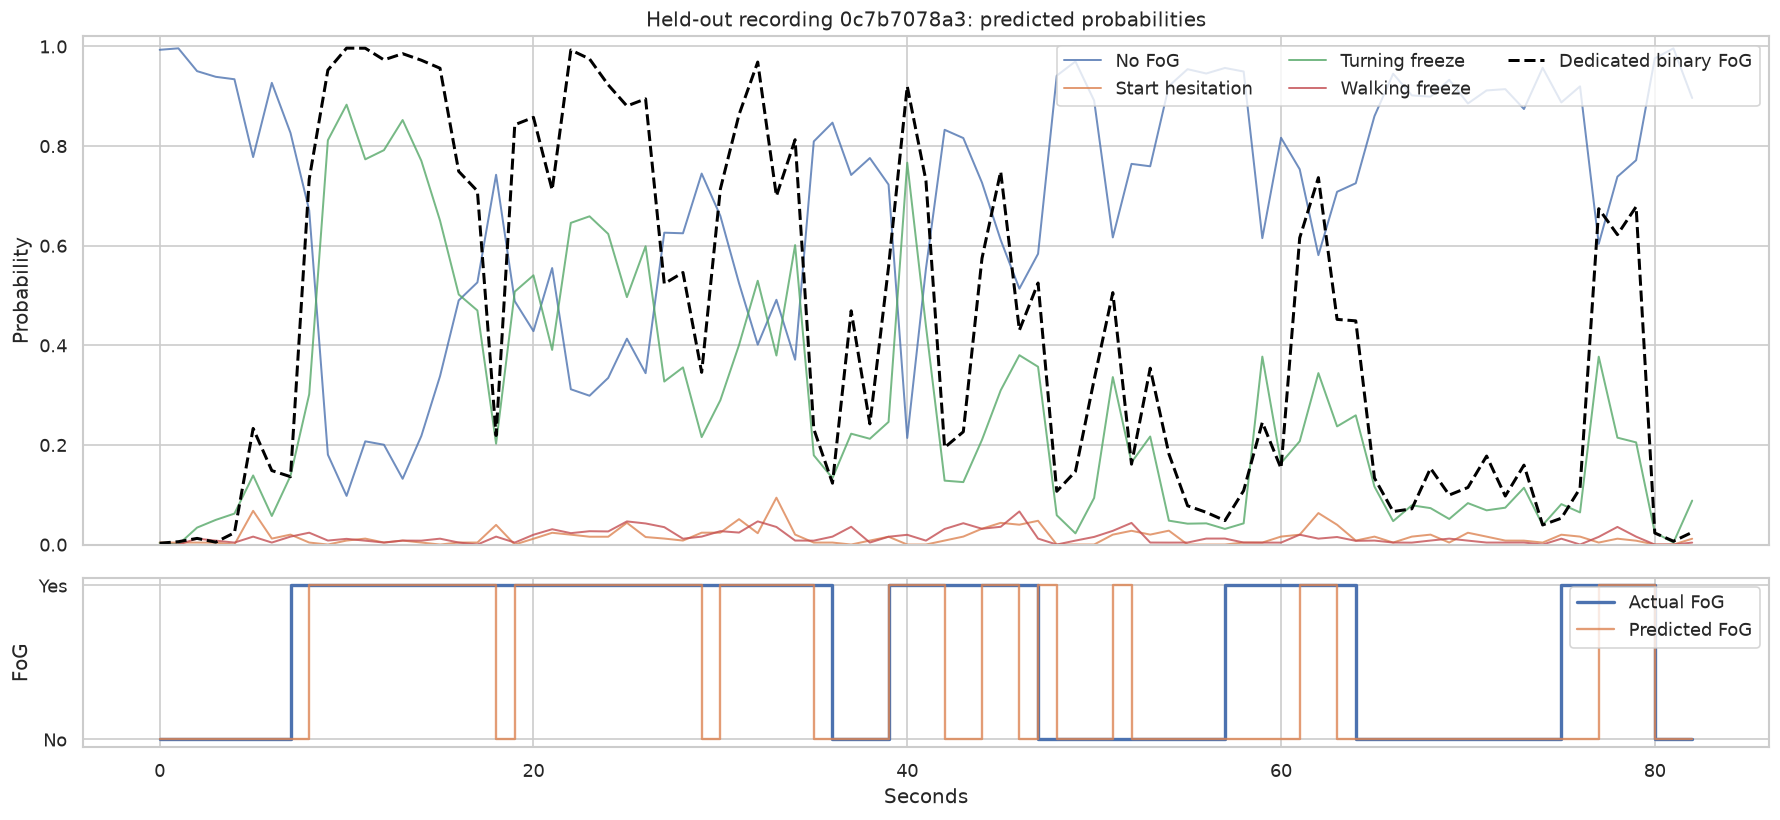

In [10]:
test_results[[f"p_{index}" for index in range(len(CLASS_NAMES))]] = probabilities
example_test_id = test_results.groupby("Id")["actual_fog"].sum().idxmax()
timeline = test_results[test_results["Id"] == example_test_id].sort_values("window_start_s")

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
for class_index, class_name in enumerate(CLASS_NAMES):
    axes[0].plot(timeline["window_start_s"], timeline[f"p_{class_index}"], label=class_name, linewidth=1.2, alpha=0.8)
axes[0].plot(timeline["window_start_s"], timeline["fog_probability"], label="Dedicated binary FoG", color="black", linestyle="--", linewidth=1.8)
axes[0].set(title=f"Held-out recording {example_test_id}: predicted probabilities", ylabel="Probability", ylim=(0, 1.02))
axes[0].legend(ncol=3, loc="upper right")
axes[1].step(timeline["window_start_s"], timeline["actual_fog"].astype(int), where="post", label="Actual FoG", linewidth=2)
axes[1].step(timeline["window_start_s"], timeline["predicted_fog"].astype(int), where="post", label="Predicted FoG", linewidth=1.4, alpha=0.8)
axes[1].set(xlabel="Seconds", ylabel="FoG", yticks=[0, 1], yticklabels=["No", "Yes"])
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

## Save reproducible artifacts

Evaluated artifacts retain the untouched-test design. Deployment artifacts for both binary FoG detection and event-type classification are refitted on all available subjects after evaluation. Every bundle includes feature order, class names, sampling rate, and window settings.

In [11]:
configuration = {
    "sampling_rate_hz": FS,
    "window_seconds": WINDOW_SECONDS,
    "window_samples": WINDOW_SIZE,
    "hop_samples": HOP_SIZE,
    "minimum_event_fraction": MIN_EVENT_FRACTION,
}
evaluated_bundle = {
    "model": best_model,
    "feature_columns": feature_columns,
    "class_names": CLASS_NAMES,
    "configuration": configuration,
    "held_out_subjects": test_subjects,
}
final_model = clone(models[best_name]).fit(X, y)
final_bundle = {
    "model": final_model,
    "feature_columns": feature_columns,
    "class_names": CLASS_NAMES,
    "configuration": configuration,
}
binary_evaluated_bundle = {
    "model": binary_model,
    "feature_columns": feature_columns,
    "class_names": ["No FoG", "FoG"],
    "configuration": configuration,
    "held_out_subjects": test_subjects,
}
binary_final_model = clone(binary_models[binary_best_name]).fit(X, y > 0)
binary_final_bundle = {
    "model": binary_final_model,
    "feature_columns": feature_columns,
    "class_names": ["No FoG", "FoG"],
    "configuration": configuration,
}

joblib.dump(evaluated_bundle, MODEL_DIR / "fog_event_model_evaluated.joblib")
joblib.dump(final_bundle, MODEL_DIR / "fog_event_model_final.joblib")
joblib.dump(binary_evaluated_bundle, MODEL_DIR / "fog_binary_model_evaluated.joblib")
joblib.dump(binary_final_bundle, MODEL_DIR / "fog_binary_model_final.joblib")
test_results.to_csv(PROCESSED_DIR / "held_out_predictions.csv", index=False)
cv_results.to_csv(PROCESSED_DIR / "cross_validation_results.csv", index=False)
binary_cv_results.to_csv(PROCESSED_DIR / "binary_cross_validation_results.csv", index=False)

metrics_export = {
    "event_type_model": best_name,
    "event_type_macro_f1": float(holdout_metrics["macro F1"]),
    "event_type_balanced_accuracy": float(holdout_metrics["balanced accuracy"]),
    "event_type_macro_average_precision": float(holdout_metrics["macro average precision"]),
    "binary_model": binary_best_name,
    "binary_fog_f1": float(binary_metrics["F1"]),
    "binary_balanced_accuracy": float(binary_metrics["balanced accuracy"]),
    "binary_average_precision": float(binary_metrics["average precision"]),
    "held_out_subjects": test_subjects,
}
with open(PROCESSED_DIR / "evaluation_metrics.json", "w") as file:
    json.dump(metrics_export, file, indent=2)

print(f"Saved event-type and binary model bundles to {MODEL_DIR}")
print(f"Event-type model: {best_name}")
print(f"Binary model: {binary_best_name}")

Saved event-type and binary model bundles to /home/mathew/Arrakis/da-mp/models
Event-type model: Balanced random forest
Binary model: Balanced histogram boosting


## Interpretation and limitations

- The model detects annotated FoG event windows; it does **not** diagnose Parkinson's disease or assign a clinical severity stage.
- Patient-grouped evaluation is more realistic than random-window splitting, but the retained data still come from a controlled FoG-provoking protocol.
- Start-hesitation and walking-freeze windows are much rarer than turning freezes, so their confidence intervals and per-class results matter more than overall accuracy.
- A phone deployment would require a fixed lower-back/waist position, matching units and sampling rate, orientation handling, probability smoothing, and prospective validation on phone recordings.
- UPDRS and NFOG-Q describe related but distinct constructs. Associations with predicted FoG burden should remain exploratory rather than being converted directly into “mild/moderate/severe” patient labels.